In [1]:
import numpy as np
import pandas as pd
import sys  
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
from matplotlib.lines import Line2D
import cmocean
print("Modules imported")


Modules imported


In [2]:
#plot tidally filtered signals for run25 (event removed) and run26, use outputs_regular_run for run25

In [3]:
# velocity = data.horizontalVelX.isel(time=40, nSCHISM_vgrid_layers=0).values

import re 
file="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_25/station.in"
station_id =[]
with open(file) as f:
    f.readline()
    for station in range(int(f.readline())):
        line = f.readline()
        if '!' in line:
            station_id.append(line.split('!')[-1])
        else:
            station_id.append(None)
# print(station_id)

print(len(station_id))

stations = []
for sublist in station_id:
    match = re.search(r'"(.*?)"', sublist)
    if match:
        stations.append(match.group(1).strip())
    else :
        stations.append(sublist.replace("\n", "").strip())
print(len(set(stations)))


for i, station in enumerate(stations):
    print("%d == %s" % (i,station))


306
277
0 == San Joaquin at Antioch
1 == Mokelumne River at Benson's Ferry
2 == Cache Slough
3 == Cache Creek at Yolo
4 == Old River at Coney Island
5 == Clifton Court
6 == Discovery Bay at Indian Slough
7 == Doughty Cut above Grant Line Canal
8 == Sacramento River at Emmaton
9 == Sacramento River at Emmaton
10 == emm upper Emmaton
11 == emm lower Emmaton
12 == Farrar Park
13 == Grant Line Canal at Tracy Rd Bridge
14 == Green's Landing
15 == Harvey O Banks PP
16 == Holland Tract
17 == Harvey O Banks PP
18 == CCWD Old River near Discovery Bay
19 == CCWD Rock Slough PP
20 == Italian Slough Headwater near Byron
21 == Jersey Point
22 == Sacramento River at Mallard Island
23 == Sacramento River at Mallard Island
24 == Middle River at Howard Rd Bridge
25 == San Joaquin at Mossdale Bridge
26 == Middle River at Tracy Blvd
27 == Old River Barrier near DMC (Above)
28 == Old River below Dam
29 == Old River at Bacon Island
30 == Old River at Head
31 == Old River at Byron
32 == Prisoners Point
33 =

In [5]:
#load the filtered station data
dtformat = '%Y-%m-%d %H:%M:%S'
run13=pd.read_csv("/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_25/outputs_regular_run/staout_6_filt.csv")
run13['datetime']=pd.to_datetime(run13['time'],format=dtformat)
run13.set_index("datetime",inplace=True)
run14=pd.read_csv("/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_26/outputs_regular_run/staout_6_filt.csv")
run14['datetime']=pd.to_datetime(run14['time'],format=dtformat)
run14.set_index("datetime",inplace=True)
run14


,time,1,2,3,4,5,6,7,8,9,...,297,298,299,300,301,302,303,304,305,306
datetime,,,,,,,,,,,,,,,,,,,,,
2018-09-01 00:00:00,2018-09-01 00:00:00,1.448659,0.063651,0.082010,-9999.0,0.172086,0.257478,0.319735,0.262084,0.256140,...,0.456104,-999.000272,-731.866713,0.603463,0.536082,-9999.0,-9999.0,0.170361,0.185603,0.184258
2018-09-01 00:15:00,2018-09-01 00:15:00,1.448530,0.063650,0.082011,-9999.0,0.172035,0.257488,0.319853,0.262067,0.256008,...,0.456012,-999.000254,-731.099452,0.602043,0.534817,-9999.0,-9999.0,0.170314,0.185587,0.184218
2018-09-01 00:30:00,2018-09-01 00:30:00,1.448414,0.063649,0.082013,-9999.0,0.171983,0.257496,0.319970,0.262052,0.255878,...,0.455919,-999.000230,-730.339717,0.600627,0.533557,-9999.0,-9999.0,0.170268,0.185570,0.184177
2018-09-01 00:45:00,2018-09-01 00:45:00,1.448313,0.063649,0.082014,-9999.0,0.171930,0.257503,0.320087,0.262038,0.255748,...,0.455825,-999.000199,-729.588462,0.599213,0.532305,-9999.0,-9999.0,0.170222,0.185551,0.184135
2018-09-01 01:00:00,2018-09-01 01:00:00,1.448225,0.063648,0.082015,-9999.0,0.171876,0.257509,0.320204,0.262026,0.255619,...,0.455731,-999.000160,-728.846579,0.597804,0.531059,-9999.0,-9999.0,0.170176,0.185532,0.184092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-10-30 23:00:00,2018-10-30 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-30 23:15:00,2018-10-30 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-30 23:30:00,2018-10-30 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
run14['115']

datetime
2018-09-01 00:00:00    0.296355
2018-09-01 00:15:00    0.296250
2018-09-01 00:30:00    0.296144
2018-09-01 00:45:00    0.296037
2018-09-01 01:00:00    0.295928
                         ...   
2018-10-30 23:00:00         NaN
2018-10-30 23:15:00         NaN
2018-10-30 23:30:00         NaN
2018-10-30 23:45:00         NaN
2018-10-31 00:00:00         NaN
Name: 115, Length: 5761, dtype: float64

In [7]:
#load the unfiltered data
columns = ['time']
stations_no = [str(i) for i in range(306)]
columns = columns + stations_no

run13_r=pd.read_csv("/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_25/outputs_regular_run/staout_6", sep='\\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run13_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta]  
run13_r['time'] = timestamp
run13_r.set_index("time",inplace=True)
run14_r=pd.read_csv("/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_26/outputs/staout_6", sep='\\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run14_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta] 
run14_r['time'] = timestamp
run14_r.set_index("time",inplace=True)


In [8]:
# timestamp

<Axes: xlabel='time'>

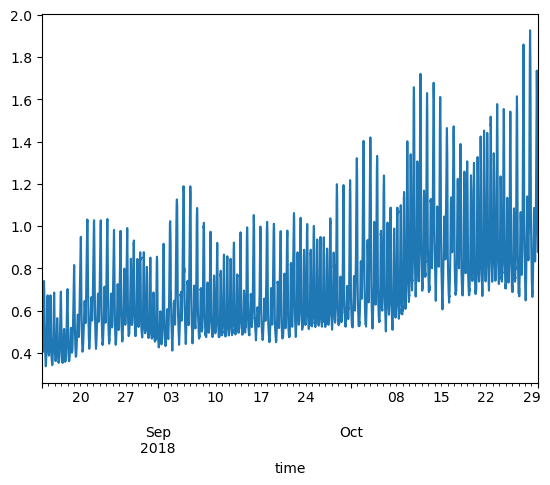

In [9]:
run13_r['115'].plot()

In [10]:
np.max(run13_r['115'])

1.92637

In [11]:
stations[10]

'emm upper Emmaton'

In [12]:
run13.index

DatetimeIndex(['2018-09-01 00:00:00', '2018-09-01 00:15:00',
               '2018-09-01 00:30:00', '2018-09-01 00:45:00',
               '2018-09-01 01:00:00', '2018-09-01 01:15:00',
               '2018-09-01 01:30:00', '2018-09-01 01:45:00',
               '2018-09-01 02:00:00', '2018-09-01 02:15:00',
               ...
               '2018-10-29 21:45:00', '2018-10-29 22:00:00',
               '2018-10-29 22:15:00', '2018-10-29 22:30:00',
               '2018-10-29 22:45:00', '2018-10-29 23:00:00',
               '2018-10-29 23:15:00', '2018-10-29 23:30:00',
               '2018-10-29 23:45:00', '2018-10-30 00:00:00'],
              dtype='datetime64[ns]', name='datetime', length=5665, freq=None)

Axes(0.125,0.11;0.775x0.77)


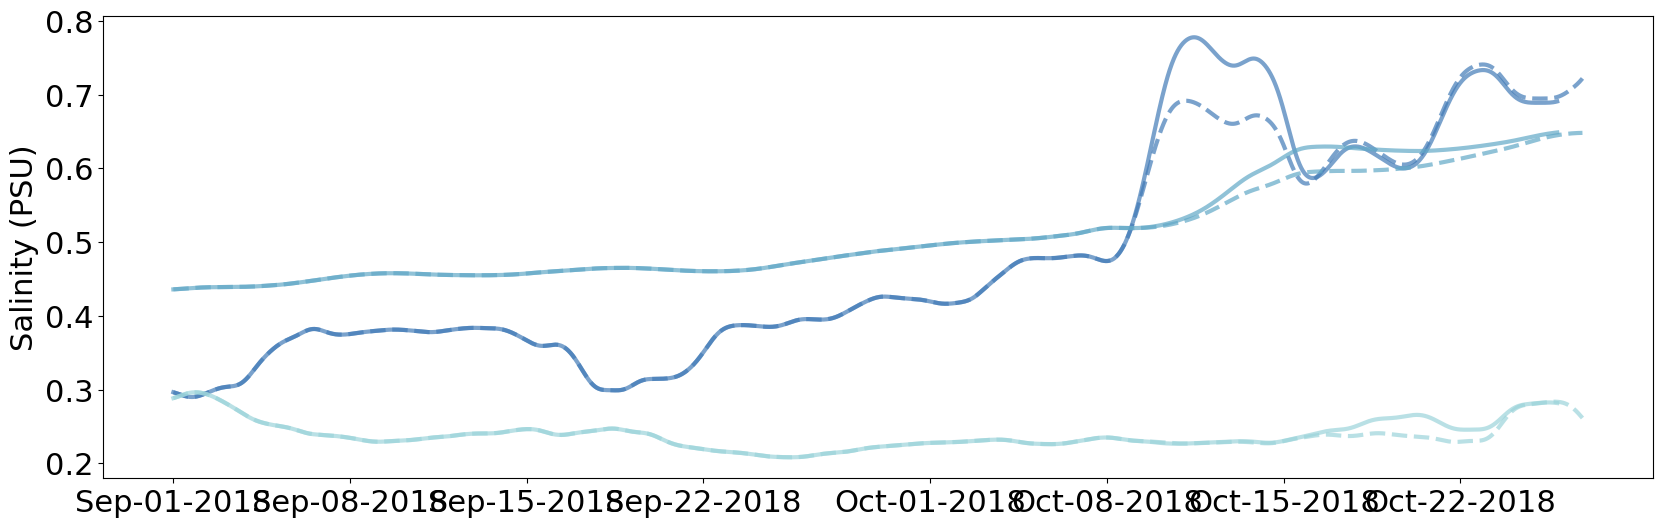

In [13]:
#plot the 3 stations
# something is up with Jersey point filtered data 

#station_indices=[21,202,159] #Jersey Point, Franks Tract Mid Tract, Holland Cut near Bethel Island
station_indices=[115,202,159] #sjj Jersey Point, Franks Tract Mid Tract, Holland Cut near Bethel Island
fig = plt.figure(figsize=(20,6))
mpl.rcParams.update({'font.size': 22})
ax = plt.gca()
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 115:
       s=2
    if idx == 202:
       s=3
    if idx == 159:
        s=4
    values1 = run13[str(idx)]
    values2 = run14[str(idx)]
       
    ax.plot(values1, label = 'Historical '+stations[idx], linewidth=3, alpha =0.7, color=cmocean.cm.ice((s+1)/6))
    ax.plot(values2, label = 'Event Removed ' +stations[idx], linewidth=3, alpha =0.7,linestyle='--', color=cmocean.cm.ice((s+1)/6))
    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax.set_ylabel('Salinity (PSU)')
plt.show()
# ax.grid()


In [14]:
values1

datetime
2018-09-01 00:00:00    0.288354
2018-09-01 00:15:00    0.288460
2018-09-01 00:30:00    0.288567
2018-09-01 00:45:00    0.288676
2018-09-01 01:00:00    0.288788
                         ...   
2018-10-29 23:00:00         NaN
2018-10-29 23:15:00         NaN
2018-10-29 23:30:00         NaN
2018-10-29 23:45:00         NaN
2018-10-30 00:00:00         NaN
Name: 159, Length: 5665, dtype: float64

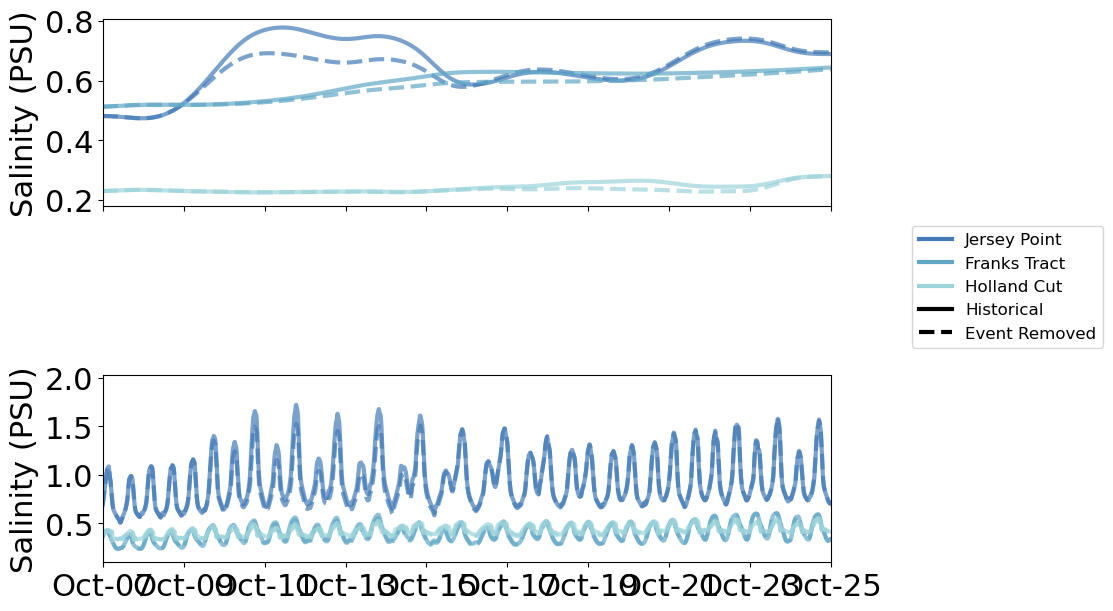

In [15]:
#plot the 3 stations

station_indices=[115,202,159] #Jersey Point, Franks Tract Mid Tract, Holland Cut near Bethel Island
fig, ax = plt.subplots(2,1,layout='constrained',sharex=True,figsize=[11,6])
mpl.rcParams.update({'font.size': 12})

# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 115:
        s=2
    if idx == 202:
        s=3
    if idx == 159:
        s=4
    values1 = run13[str(idx)]
    values2 = run14[str(idx)]
    values3 = run13_r[str(idx)]
    values4 = run14_r[str(idx)]
       
    ax[0].plot(values1, label = 'Historical '+stations[idx], linewidth=3, alpha =0.7, color=cmocean.cm.ice((s+1)/6))
    ax[0].plot(values2, label = 'Event Removed ' +stations[idx], linewidth=3, alpha =0.7,linestyle='--', color=cmocean.cm.ice((s+1)/6))

# plot the unfiltered below
    ax[1].plot(values3, label = 'Historical '+stations[idx], linewidth=3, alpha =0.7, color=cmocean.cm.ice((s+1)/6))
    ax[1].plot(values4, label = 'Event Removed ' +stations[idx], linewidth=3, alpha =0.7,linestyle='--', color=cmocean.cm.ice((s+1)/6))

color_dict= {'Jersey Point': cmocean.cm.ice(3/6),
             'Franks Tract': cmocean.cm.ice(4/6),
             'Holland Cut': cmocean.cm.ice(5/6)}
style_dict={'Historical':'-',
            'Event Removed':'--'}
overall_dict= color_dict | style_dict
# color_dict= {'Point Reyes Tide Gauge': 'maroon',
#              'Monterey Tide Gauge': 'brown',
#              'Jersey Point EC': 'green',
#              'Holland Cut EC': 'skyblue',
#              'Franks Tract EC':'yellow'}
#stations_latlon=stations.to_crs(epsg=4326)


custom_points1=[Line2D([0], [0],linestyle='-',linewidth=3, color=c) for c in color_dict.values()]
custom_points2=[Line2D([0], [0],linestyle=s,linewidth=3, color='k') for s in style_dict.values()]
custom_points=custom_points1+custom_points2 # concatenate the lists

#leg = plt.legend(handles=[a,b,c,d,e,f,g],loc='upper right', bbox_to_anchor=(1.8, 2.0))
leg = plt.legend(custom_points, overall_dict.keys(),bbox_to_anchor=(1.1, 1.1))

ax[1].set_xlim(pd.to_datetime("2018-10-07"),pd.to_datetime("2018-10-25")) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax[0].set_ylabel('Salinity (PSU)')
ax[1].set_ylabel('Salinity (PSU)')
plt.show()
# ax.grid()
fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/2018_event_removed.png')

In [16]:
# water level event start and end
# 2018-10-29 23:00:00 
strimpr=pd.to_datetime('2018-10-09 00:06:00',format=dtformat)
etrimpr=pd.to_datetime('2018-10-15 10:18:00',format=dtformat)

In [17]:
dtformat

'%Y-%m-%d %H:%M:%S'

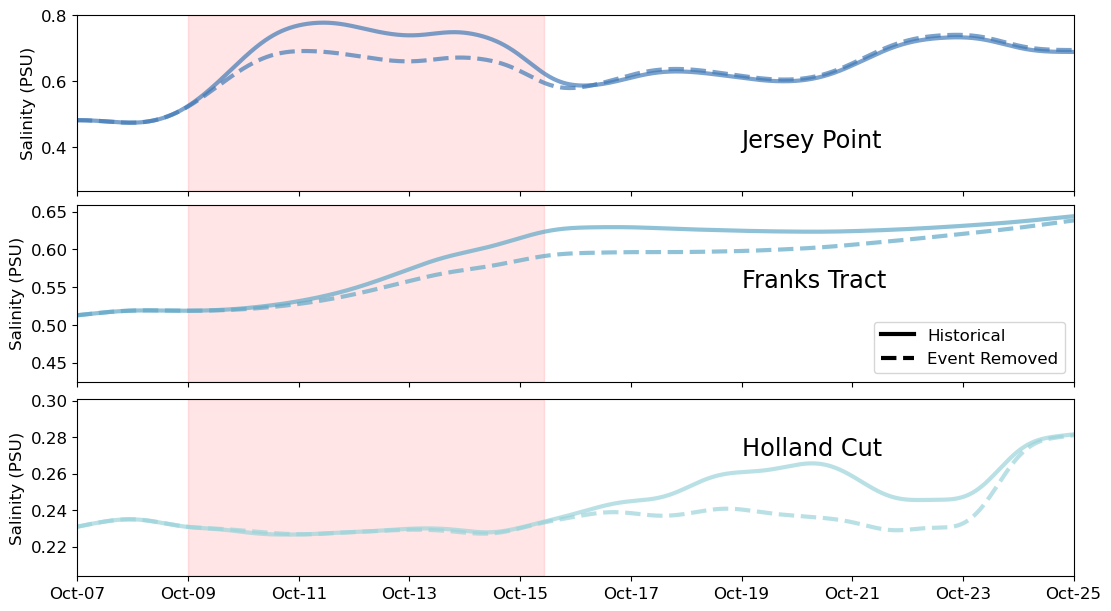

In [18]:
#plot the 3 stations

station_indices=[115,202,159] #Jersey Point, Franks Tract Mid Tract, Holland Cut near Bethel Island
fig, ax = plt.subplots(3,1,layout='constrained',sharex=True,figsize=[11,6])
mpl.rcParams.update({'font.size': 12})

# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 115:
        s=2
        an=0
    if idx == 202:
        s=3
        an=1
    if idx == 159:
        s=4
        an=2
    values1 = run13[str(idx)]
    values2 = run14[str(idx)]
    values3 = run13_r[str(idx)]
    values4 = run14_r[str(idx)]
       
    ax[an].plot(values1, label = 'Historical '+stations[idx], linewidth=3, alpha =0.7, color=cmocean.cm.ice((s+1)/6))
    ax[an].plot(values2, label = 'Event Removed ' +stations[idx], linewidth=3, alpha =0.7,linestyle='--', color=cmocean.cm.ice((s+1)/6))


color_dict= {'Jersey Point': cmocean.cm.ice(3/6),
             'Franks Tract': cmocean.cm.ice(4/6),
             'Holland Cut': cmocean.cm.ice(5/6)}
style_dict={'Historical':'-',
            'Event Removed':'--'}
overall_dict= color_dict | style_dict
# color_dict= {'Point Reyes Tide Gauge': 'maroon',
#              'Monterey Tide Gauge': 'brown',
#              'Jersey Point EC': 'green',
#              'Holland Cut EC': 'skyblue',
#              'Franks Tract EC':'yellow'}
#stations_latlon=stations.to_crs(epsg=4326)


custom_points1=[Line2D([0], [0],linestyle='-',linewidth=3, color=c) for c in color_dict.values()]
custom_points2=[Line2D([0], [0],linestyle=s,linewidth=3, color='k') for s in style_dict.values()]
custom_points=custom_points1+custom_points2 # concatenate the lists

#leg = plt.legend(handles=[a,b,c,d,e,f,g],loc='upper right', bbox_to_anchor=(1.8, 2.0))
#leg = plt.legend(custom_points, overall_dict.keys(),bbox_to_anchor=(1.1, 1.1))
ax[1].legend(custom_points2, style_dict.keys())#,bbox_to_anchor=(1.1, 1.1))

# highlight a time range
ax[0].axvspan(strimpr, etrimpr, color="red", alpha=0.1)
ax[1].axvspan(strimpr, etrimpr, color="red", alpha=0.1)
ax[2].axvspan(strimpr, etrimpr, color="red", alpha=0.1)

#annotate
ax[0].text(pd.to_datetime('2018-10-19 00:00:00',format=dtformat), 0.4,'Jersey Point',size='x-large')
ax[1].text(pd.to_datetime('2018-10-19 00:00:00',format=dtformat), 0.55,'Franks Tract',size='x-large')
ax[2].text(pd.to_datetime('2018-10-19 00:00:00',format=dtformat), 0.27,'Holland Cut',size='x-large')

ax[2].set_xlim(pd.to_datetime("2018-10-07"),pd.to_datetime("2018-10-25")) #July 1 to end
# # ax.grid(which='major', color='b', linestyle='-')
# #ax.set_title("Salinity from baroclinic run")
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax[0].set_ylabel('Salinity (PSU)')
ax[1].set_ylabel('Salinity (PSU)')
ax[2].set_ylabel('Salinity (PSU)')
plt.show()
# ax.grid()
#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/2018_event_removed_salinity_3_plots.png')

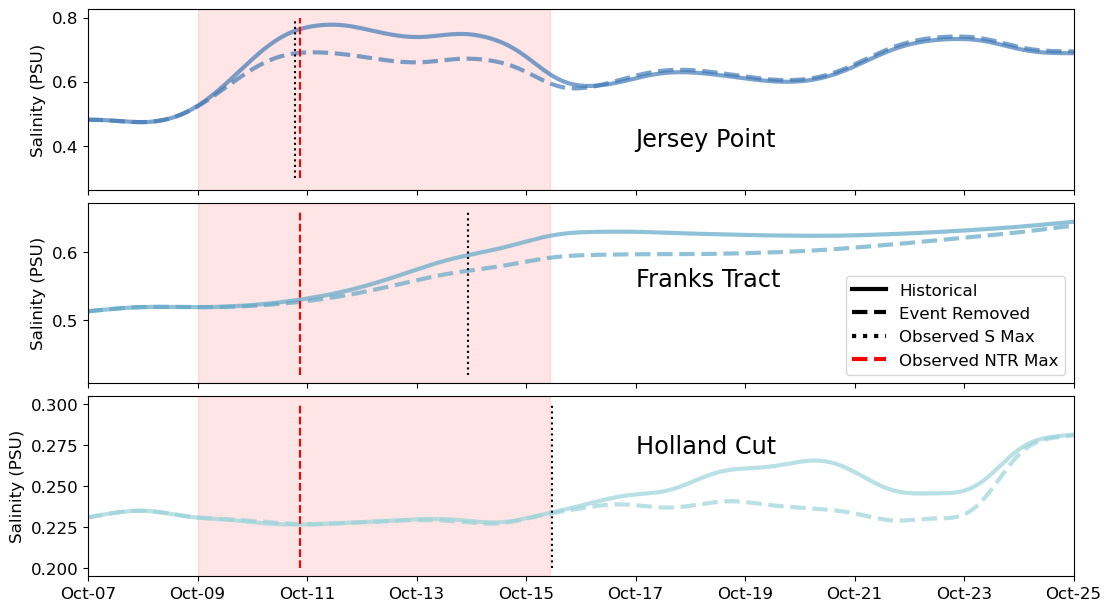

In [29]:
#plot the 3 stations

station_indices=[115,202,159] #Jersey Point, Franks Tract Mid Tract, Holland Cut near Bethel Island
fig, ax = plt.subplots(3,1,layout='constrained',sharex=True,figsize=[11,6])
mpl.rcParams.update({'font.size': 12})

# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 115:
        s=2
        an=0
    if idx == 202:
        s=3
        an=1
    if idx == 159:
        s=4
        an=2
    values1 = run13[str(idx)]
    values2 = run14[str(idx)]
    values3 = run13_r[str(idx)]
    values4 = run14_r[str(idx)]
       
    ax[an].plot(values1, label = 'Historical '+stations[idx], linewidth=3, alpha =0.7, color=cmocean.cm.ice((s+1)/6))
    ax[an].plot(values2, label = 'Event Removed ' +stations[idx], linewidth=3, alpha =0.7,linestyle='--', color=cmocean.cm.ice((s+1)/6))


color_dict= {'Jersey Point': cmocean.cm.ice(3/6),
             'Franks Tract': cmocean.cm.ice(4/6),
             'Holland Cut': cmocean.cm.ice(5/6)}
style_dict={'Historical':'-',
            'Event Removed':'--',
           'Observed S Max':':'}
other_dict={'Observed NTR Max':'r'}
overall_dict= style_dict | other_dict
# overall_dict= color_dict | style_dict
# color_dict= {'Point Reyes Tide Gauge': 'maroon',
#              'Monterey Tide Gauge': 'brown',
#              'Jersey Point EC': 'green',
#              'Holland Cut EC': 'skyblue',
#              'Franks Tract EC':'yellow'}
#stations_latlon=stations.to_crs(epsg=4326)


#custom_points1=[Line2D([0], [0],linestyle='-',linewidth=3, color=c) for c in color_dict.values()]
custom_points2=[Line2D([0], [0],linestyle=s,linewidth=3, color='k') for s in style_dict.values()]
custom_points3=[Line2D([0], [0],linestyle='--',linewidth=3, color=c) for c in other_dict.values()]
# custom_points=custom_points1+custom_points2 # concatenate the lists
custom_points=custom_points2+custom_points3 # concatenate the lists

#leg = plt.legend(handles=[a,b,c,d,e,f,g],loc='upper right', bbox_to_anchor=(1.8, 2.0))
#leg = plt.legend(custom_points, overall_dict.keys(),bbox_to_anchor=(1.1, 1.1))
ax[1].legend(custom_points, overall_dict.keys())#,bbox_to_anchor=(1.1, 1.1))

# highlight a time range
ax[0].axvspan(strimpr, etrimpr, color="red", alpha=0.1)
ax[1].axvspan(strimpr, etrimpr, color="red", alpha=0.1)
ax[2].axvspan(strimpr, etrimpr, color="red", alpha=0.1)

#annotate
ax[0].text(pd.to_datetime('2018-10-17 00:00:00',format=dtformat), 0.4,'Jersey Point',size='x-large')
ax[1].text(pd.to_datetime('2018-10-17 00:00:00',format=dtformat), 0.55,'Franks Tract',size='x-large')
ax[2].text(pd.to_datetime('2018-10-17 00:00:00',format=dtformat), 0.27,'Holland Cut',size='x-large')

ax[2].set_xlim(pd.to_datetime("2018-10-07"),pd.to_datetime("2018-10-25")) #July 1 to end
# # ax.grid(which='major', color='b', linestyle='-')
# #ax.set_title("Salinity from baroclinic run")
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax[0].set_ylabel('Salinity (PSU)')
ax[1].set_ylabel('Salinity (PSU)')
ax[2].set_ylabel('Salinity (PSU)')

#add a vertical red dashed line for where the Point Reyes max was 
ax[0].vlines(pd.to_datetime('2018-10-10 21:00:00',format=dtformat),0.3,0.8,colors='r',linestyles='--')
ax[1].vlines(pd.to_datetime('2018-10-10 21:00:00',format=dtformat),0.42,0.66,colors='r',linestyles='--')
ax[2].vlines(pd.to_datetime('2018-10-10 21:00:00',format=dtformat),0.2,0.3,colors='r',linestyles='--')

#add a dotted vertical black line when the observed station max was
ax[0].vlines(pd.to_datetime('2018-10-10 18:45:00',format=dtformat),0.3,0.8,colors='k',linestyles=':')
ax[1].vlines(pd.to_datetime('2018-10-13 22:45:00',format=dtformat),0.42,0.66,colors='k',linestyles=':')
ax[2].vlines(pd.to_datetime('2018-10-15 11:30:00',format=dtformat),0.2,0.3,colors='k',linestyles=':')



#add an X for the observed max value at each station


plt.show()
# ax.grid()
#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/manuscript_figures/2018_event_removed_salinity_3_plots_more_annotations.png')

# Calculate the difference between the curves, compute what and when the max happens

In [30]:
jp_diff=run13[str(115)]-run14[str(115)]
frk_diff=run13[str(202)]-run14[str(202)]
hol2_diff=run13[str(159)]-run14[str(159)]

In [34]:
print(jp_diff.max())
print(jp_diff.idxmax())
print(frk_diff.max())
print(frk_diff.idxmax())
print(hol2_diff.max())
print(hol2_diff.idxmax())

0.0900597897053016
2018-10-11 17:00:00
0.03369459761950022
2018-10-16 04:45:00
0.029501485898939278
2018-10-20 09:00:00


In [20]:
#What is the time of the max salinity during the event?
eventrange=run13_r['21'].loc[pd.to_datetime("2020-10-17"):pd.to_datetime("2020-10-28")]
eventrange.idxmax()

ValueError: attempt to get argmax of an empty sequence